# Mini-Project 3: Predictive Modeling and Optimization for Real Estate Investment

**Question:** How can a real estate company use house features to predict property value and make better investment decisions under a limited renovation budget?

This notebook combines a **neural network** for price prediction with a **linear program** for budget-constrained property selection on the Ames Housing dataset.

## Setup & Data Loading

Imports and a quick look at the raw dataset (2,930 rows, 82 columns).

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.show_dimensions", False)
os.makedirs("assets", exist_ok=True)

def save_fig(name):
    plt.savefig(f"assets/{name}.png", dpi=120, bbox_inches="tight")

In [2]:
df = pd.read_csv("data/ames_housing.csv")
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [3]:
df.shape

(2930, 82)

---

## Part 1: Feature Selection and Problem Framing

**Target:** `SalePrice`, a dollar amount. This is a **regression** problem (we want a price, not a category).

**Selected features (8):**

| Feature | Why |
|---|---|
| `Overall Qual` | Top-correlated feature in Ames (overall material and finish quality) |
| `Gr Liv Area` | Above-grade living area, the main size driver |
| `Total Bsmt SF` | Basement size, extra usable space |
| `Garage Cars` | Garage capacity, a strong amenity signal |
| `Year Built` | Newer houses usually sell for more |
| `Year Remod/Add` | When the house was last renovated, directly relevant to Part 4 |
| `Neighborhood` | Location, location, location |
| `Full Bath` | Bathroom count |

> *Note: we initially picked `Lot Area` but swapped it for `Year Remod/Add`. `Lot Area` is heavily right-skewed (skew 12.82) and only weakly correlated with price (0.27). `Year Remod/Add` is much better behaved (skew -0.45) and ties cleanly into Part 4. Val and test scores were within noise either way.*

Quick sanity check on dtypes, ranges, and missing values:

In [4]:
features = [
    "Overall Qual", "Gr Liv Area", "Total Bsmt SF", "Garage Cars",
    "Year Built", "Year Remod/Add", "Neighborhood", "Full Bath",
]
target = "SalePrice"

summary = df[features + [target]].describe(include="all").T
summary["missing"] = df[features + [target]].isna().sum()
summary["dtype"] = df[features + [target]].dtypes.astype(str)
summary[["dtype", "missing", "mean", "std", "min", "max"]]

,dtype,missing,mean,std,min,max
Overall Qual,int64,0,6.094881,1.411026,1.0,10.0
Gr Liv Area,int64,0,1499.690444,505.508887,334.0,5642.0
Total Bsmt SF,float64,1,1051.614544,440.615067,0.0,6110.0
Garage Cars,float64,1,1.766815,0.760566,0.0,5.0
Year Built,int64,0,1971.356314,30.245361,1872.0,2010.0
Year Remod/Add,int64,0,1984.266553,20.860286,1950.0,2010.0
Neighborhood,str,0,NaN,NaN,NaN,NaN
Full Bath,int64,0,1.566553,0.552941,0.0,4.0
SalePrice,int64,0,180796.060068,79886.692357,12789.0,755000.0


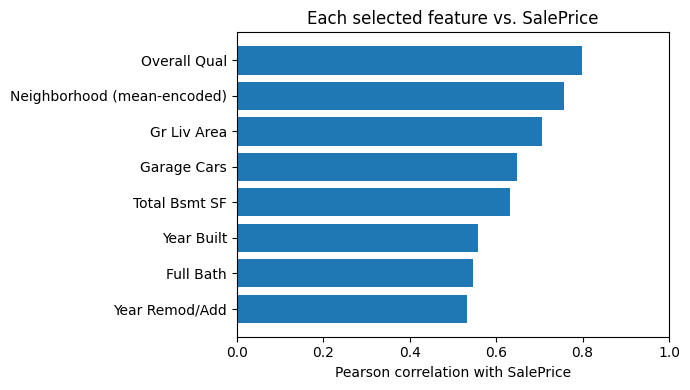

In [5]:
numeric_feats = [f for f in features if pd.api.types.is_numeric_dtype(df[f])]
numeric_corrs = df[numeric_feats + [target]].corr()[target].drop(target)
neigh_target_mean = df.groupby("Neighborhood")[target].transform("mean")
all_corrs = numeric_corrs.copy()
all_corrs["Neighborhood (mean-encoded)"] = neigh_target_mean.corr(df[target])
all_corrs = all_corrs.sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["tab:gray" if abs(v) < 0.3 else "tab:blue" for v in all_corrs]
ax.barh(all_corrs.index, all_corrs.values, color=colors)
ax.axvline(0, color="black", lw=0.5)
ax.set_xlabel(f"Pearson correlation with {target}")
ax.set_title("Each selected feature vs. SalePrice")
ax.set_xlim(0, 1)
plt.tight_layout()
save_fig("feature_correlations")
plt.show()

---

## Part 2: Data Preparation and Baseline

**Preprocessing:** drop the 2 rows with missing values (negligible loss out of 2,930), one-hot encode `Neighborhood`, standard-scale numerics. The target is also standard-scaled internally so the NN trains on a well-behaved range.

**Splits:** 64% train, 16% val, 20% test (two nested 80/20 splits, fixed seed). The val set is for comparing architectures and tuning hyperparameters, so we don't peek at test during model selection. Test is kept for the final report.

**Metric:** RMSE in dollars (same units as `SalePrice`, and it penalizes big misses, which matter for investment decisions). Also report MAE and R^2.

**Baseline:** predict the training mean for every row. Any real model has to beat this.

In [6]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = ["Overall Qual", "Gr Liv Area", "Total Bsmt SF",
                    "Garage Cars", "Year Built", "Year Remod/Add", "Full Bath"]
categorical_features = ["Neighborhood"]

df_clean = df.dropna(subset=features).reset_index(drop=True)
print(f"Dropped {len(df) - len(df_clean)} rows with missing values; {len(df_clean)} remain.")

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
])

X = df_clean[features]
y = df_clean[target].astype(float).values

X_trainval_raw, X_test_raw, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_trainval_raw, y_trainval, test_size=0.2, random_state=42
)

X_train = preprocessor.fit_transform(X_train_raw)
X_val = preprocessor.transform(X_val_raw)
X_test = preprocessor.transform(X_test_raw)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Dropped 2 rows with missing values; 2928 remain.
Train: (1873, 35), Val: (469, 35), Test: (586, 35)


In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def score(name, split, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name:>14} [{split}] | RMSE ${rmse:>9,.0f} | MAE ${mae:>9,.0f} | R^2 {r2:.3f}")
    return {"model": name, "split": split, "RMSE": rmse, "MAE": mae, "R2": r2}

results = []
mean_pred = y_train.mean()
results.append(score("Baseline", "val",  y_val,  np.full_like(y_val,  mean_pred)))
results.append(score("Baseline", "test", y_test, np.full_like(y_test, mean_pred)))

      Baseline [val] | RMSE $   82,349 | MAE $   58,043 | R^2 -0.001
      Baseline [test] | RMSE $   90,756 | MAE $   62,593 | R^2 -0.002


---

## Part 3: Neural Network Modeling

Train **four architectures** to probe the depth-vs-width trade-off, compare on the **val set**, then report the winner's score on test.

| Model | Architecture | Probes |
|---|---|---|
| NN-A | (32,) | low-capacity baseline |
| NN-B | (64, 32) | moderate depth |
| NN-C | (128,) | width without depth |
| NN-D | (64, 32, 16) | extra depth |

All trained with MSE loss / Adam / ReLU, early stopping on a 10% internal validation split.

In [8]:
from sklearn.compose import TransformedTargetRegressor
from sklearn.neural_network import MLPRegressor

def make_nn(hidden_layer_sizes, **kwargs):
    base = MLPRegressor(
        hidden_layer_sizes=hidden_layer_sizes,
        activation="relu",
        solver="adam",
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42,
        **kwargs,
    )
    return TransformedTargetRegressor(regressor=base, transformer=StandardScaler())

architectures = {
    "NN-A (32)":       {"hidden_layer_sizes": (32,)},
    "NN-B (64,32)":    {"hidden_layer_sizes": (64, 32), "alpha": 1e-3},
    "NN-C (128)":      {"hidden_layer_sizes": (128,)},
    "NN-D (64,32,16)": {"hidden_layer_sizes": (64, 32, 16), "alpha": 1e-3},
}

models = {}
for name, kwargs in architectures.items():
    m = make_nn(**kwargs)
    m.fit(X_train, y_train)
    models[name] = m
    results.append(score(name, "val",  y_val,  m.predict(X_val)))
    results.append(score(name, "test", y_test, m.predict(X_test)))

     NN-A (32) [val] | RMSE $   29,313 | MAE $   18,427 | R^2 0.873
     NN-A (32) [test] | RMSE $   33,009 | MAE $   18,241 | R^2 0.867
  NN-B (64,32) [val] | RMSE $   28,995 | MAE $   17,967 | R^2 0.876
  NN-B (64,32) [test] | RMSE $   30,474 | MAE $   17,752 | R^2 0.887


    NN-C (128) [val] | RMSE $   30,428 | MAE $   18,518 | R^2 0.863
    NN-C (128) [test] | RMSE $   30,107 | MAE $   17,717 | R^2 0.890
NN-D (64,32,16) [val] | RMSE $   29,797 | MAE $   18,252 | R^2 0.869
NN-D (64,32,16) [test] | RMSE $   32,101 | MAE $   18,308 | R^2 0.875


                      RMSE                   MAE                R2       
split                 test        val       test        val   test    val
model                                                                    
Baseline        90,756.373 82,349.311 62,592.527 58,042.939 -0.002 -0.001
NN-A (32)       33,009.145 29,312.576 18,241.183 18,427.473  0.867  0.873
NN-B (64,32)    30,473.951 28,995.074 17,752.484 17,966.804  0.887  0.876
NN-C (128)      30,107.069 30,428.345 17,716.641 18,517.601  0.890  0.863
NN-D (64,32,16) 32,100.551 29,797.180 18,308.289 18,252.231  0.875  0.869

Val winner (architecture-only): NN-B (64,32) (val R^2 0.876)


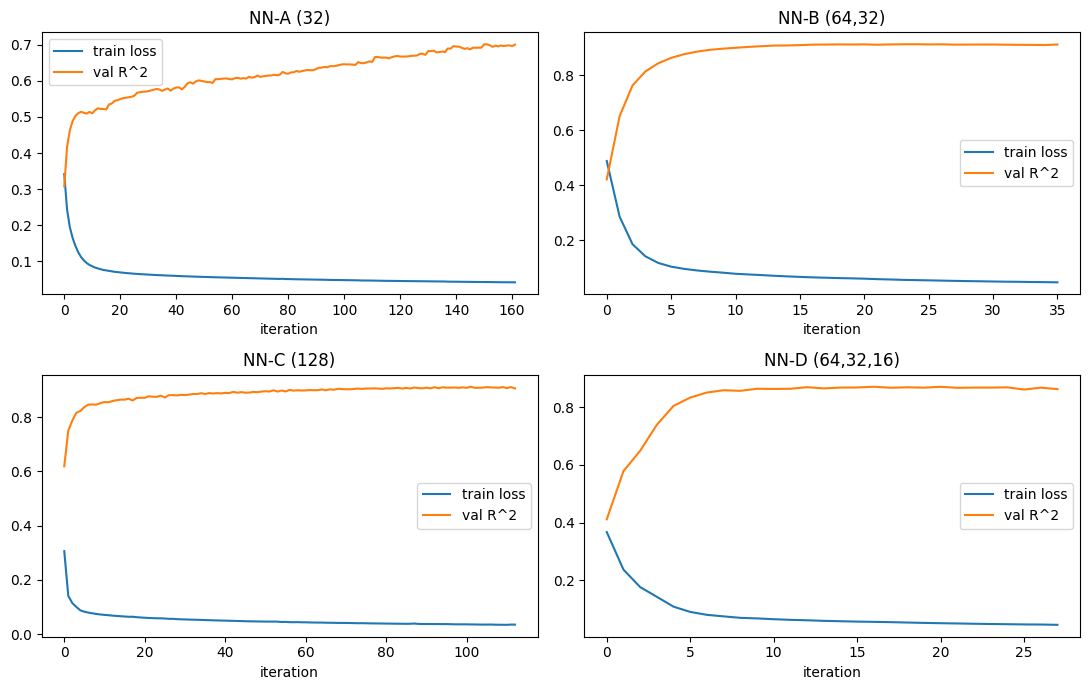

In [9]:
results_df = pd.DataFrame(results).pivot(index="model", columns="split", values=["RMSE", "MAE", "R2"])
print(results_df.to_string(float_format=lambda x: f"{x:,.3f}"))

val_scores = {r["model"]: r["R2"] for r in results if r["split"] == "val" and r["model"] != "Baseline"}
arch_winner_name = max(val_scores, key=val_scores.get)
print(f"\nVal winner (architecture-only): {arch_winner_name} (val R^2 {val_scores[arch_winner_name]:.3f})")

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, (name, model) in zip(axes.ravel(), models.items()):
    inner = model.regressor_
    ax.plot(inner.loss_curve_, label="train loss")
    if hasattr(inner, "validation_scores_"):
        ax.plot(inner.validation_scores_, label="val R^2", color="tab:orange")
    ax.set_title(name)
    ax.set_xlabel("iteration")
    ax.legend()
plt.tight_layout()
save_fig("loss_curves")
plt.show()

### 3.1 Comparison and discussion

| Model | Val R^2 | Test R^2 |
|---|---|---|
| Baseline | -0.00 | -0.00 |
| NN-A (32) | 0.873 | 0.867 |
| **NN-B (64,32)** | **0.876** | **0.887** |
| NN-C (128) | 0.863 | 0.890 |
| NN-D (64,32,16) | 0.869 | 0.875 |

All four networks beat the baseline by a wide margin and cluster between 0.86 and 0.89. Diminishing returns kick in fast at this dataset size.

**Takeaways:**
- Depth slightly beats width: the wide single-layer net (NN-C) was worst on val.
- Going past 2 layers didn't help: NN-D's third layer added complexity for no gain.
- Val and test scores match closely for every model, so no overfitting to either split.
- Gaps between top models are under 0.01 R^2, basically noise. Multiple random seeds would firm this up.

**Winner (chosen on val):** NN-B. Test R^2 0.887, RMSE about $30K.

### 3.2 Hyperparameter tuning of NN-B

Architecture is locked in. Now tune two knobs that control how the network learns:

- **`alpha`**: L2 weight decay. Bigger means more regularization (less overfitting, but risks underfitting).
- **`learning_rate_init`**: Adam's starting step size. Too small slows training; too big makes it unstable.

Grid: 4 by 3 = 12 combos. Pick the winner on val and report test for the winner.

Best combo: alpha=0.1, lr=0.01, val R^2 0.883
Tuned NN-B test:    RMSE $30,899, R^2 0.884
Original NN-B test: RMSE $30,474, R^2 0.887


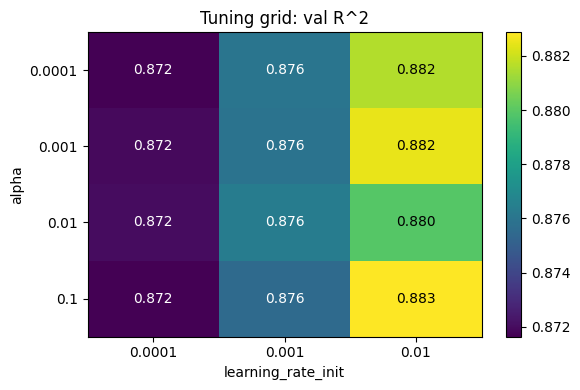

In [10]:
import itertools

alpha_grid = [1e-4, 1e-3, 1e-2, 1e-1]
lr_grid = [1e-4, 1e-3, 1e-2]

tuning_results = []
best_val_r2 = -np.inf
best_params = None
best_model = None

for alpha, lr in itertools.product(alpha_grid, lr_grid):
    m = make_nn(hidden_layer_sizes=(64, 32), alpha=alpha, learning_rate_init=lr)
    m.fit(X_train, y_train)
    val_r2 = r2_score(y_val, m.predict(X_val))
    tuning_results.append({"alpha": alpha, "lr": lr, "val_R2": val_r2})
    if val_r2 > best_val_r2:
        best_val_r2 = val_r2
        best_params = {"alpha": alpha, "lr": lr}
        best_model = m

tune_df = pd.DataFrame(tuning_results).pivot(index="alpha", columns="lr", values="val_R2")
print(f"Best combo: alpha={best_params['alpha']}, lr={best_params['lr']}, val R^2 {best_val_r2:.3f}")

orig_b = next(r for r in results if r["model"] == "NN-B (64,32)" and r["split"] == "test")
tuned_test_pred = best_model.predict(X_test)
tuned_test_rmse = np.sqrt(mean_squared_error(y_test, tuned_test_pred))
tuned_test_r2 = r2_score(y_test, tuned_test_pred)
print(f"Tuned NN-B test:    RMSE ${tuned_test_rmse:,.0f}, R^2 {tuned_test_r2:.3f}")
print(f"Original NN-B test: RMSE ${orig_b['RMSE']:,.0f}, R^2 {orig_b['R2']:.3f}")

winner = best_model

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(tune_df.values, aspect="auto", cmap="viridis")
ax.set_xticks(range(len(tune_df.columns))); ax.set_xticklabels([f"{c:g}" for c in tune_df.columns])
ax.set_yticks(range(len(tune_df.index))); ax.set_yticklabels([f"{r:g}" for r in tune_df.index])
ax.set_xlabel("learning_rate_init"); ax.set_ylabel("alpha")
ax.set_title("Tuning grid: val R^2")
for i in range(len(tune_df.index)):
    for j in range(len(tune_df.columns)):
        v = tune_df.values[i, j]
        ax.text(j, i, f"{v:.3f}", ha="center", va="center",
                color="white" if v < tune_df.values.mean() else "black")
plt.colorbar(im, ax=ax)
plt.tight_layout()
save_fig("tuning_heatmap")
plt.show()

**Tuning takeaway:** the best combo (`alpha=0.1, lr=0.01`) bumps val R^2 from 0.876 to 0.883, but test R^2 stays basically flat (0.887 to 0.884). The gain is in noise range. The heatmap is mostly flat too, so the model isn't very sensitive to these knobs. To push past R^2 0.89 we'd need more features or a different model class (e.g. gradient boosting), not finer hyperparameter sweeps.

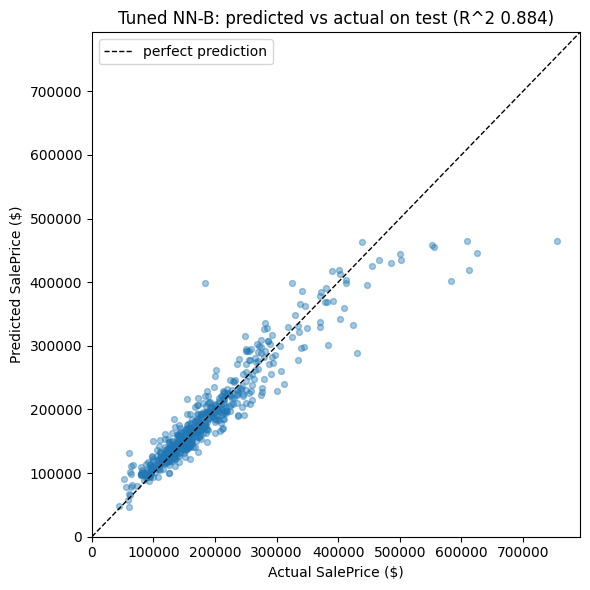

In [11]:
y_pred_test = winner.predict(X_test)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred_test, alpha=0.4, s=18)
lim = max(y_test.max(), y_pred_test.max()) * 1.05
ax.plot([0, lim], [0, lim], "k--", lw=1, label="perfect prediction")
ax.set_xlabel("Actual SalePrice ($)")
ax.set_ylabel("Predicted SalePrice ($)")
ax.set_title(f"Tuned NN-B: predicted vs actual on test (R^2 {tuned_test_r2:.3f})")
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.legend()
plt.tight_layout()
save_fig("predicted_vs_actual")
plt.show()

---

## Part 4: Optimization (Budget-Constrained House Selection)

Use the NN to drive a real decision: with a fixed renovation budget, which houses should we renovate to maximize profit?

### 4.1 Setup

For each house in the test set we simulate a renovation, then run the modified features back through the NN:

- `Overall Qual` + 1 (capped at 10)
- `Gr Liv Area` + 200 sqft
- `Year Remod/Add` set to 2010 (the renovation just happened)

Then:

- **Current value:** NN prediction on the original features.
- **Post-reno value:** NN prediction on the renovated features.
- **Uplift:** post-reno minus current.
- **Reno cost:** 10% of current value (a proxy: bigger houses cost more to renovate; sensitivity-tested in Sec. 4.4).
- **Profit:** uplift minus reno cost.

### 4.2 Linear program

- **Decision:** for each house, x_i is either 0 (skip) or 1 (renovate). Technically a 0/1 knapsack, an integer LP.
- **Objective:** maximize total profit across selected houses.
- **Constraint:** total renovation cost stays at or below the budget B.
- **Solver:** PuLP's CBC (an open-source MILP solver). We assert the solver returns "Optimal" status before trusting the output.

In [12]:
import pulp

X_test_reno_raw = X_test_raw.copy()
X_test_reno_raw["Overall Qual"] = (X_test_reno_raw["Overall Qual"] + 1).clip(upper=10)
X_test_reno_raw["Gr Liv Area"] = X_test_reno_raw["Gr Liv Area"] + 200
X_test_reno_raw["Year Remod/Add"] = 2010

X_test_reno = preprocessor.transform(X_test_reno_raw)

value_current = winner.predict(X_test)
value_reno = winner.predict(X_test_reno)
uplift = value_reno - value_current
reno_cost = 0.10 * value_current
profit = uplift - reno_cost

BUDGET = 200_000

prob = pulp.LpProblem("renovation_selection", pulp.LpMaximize)
x = [pulp.LpVariable(f"x_{i}", cat="Binary") for i in range(len(profit))]
prob += pulp.lpSum(profit[i] * x[i] for i in range(len(profit)))
prob += pulp.lpSum(reno_cost[i] * x[i] for i in range(len(profit))) <= BUDGET
prob.solve(pulp.PULP_CBC_CMD(msg=False))

selected = np.array([int(v.value()) for v in x], dtype=bool)
assert pulp.LpStatus[prob.status] == "Optimal", f"LP did not converge: {pulp.LpStatus[prob.status]}"
assert (profit[selected] >= 0).all(), "LP selected an unprofitable house"
assert reno_cost[selected].sum() <= BUDGET + 1e-6, "Budget constraint violated"

print(f"LP status:           {pulp.LpStatus[prob.status]}")
print(f"Houses selected:     {selected.sum()} / {len(selected)}")
print(f"Total reno cost:     ${reno_cost[selected].sum():>10,.0f}  (budget ${BUDGET:,})")
print(f"Total profit:        ${profit[selected].sum():>10,.0f}")
print(f"Avg profit / house:  ${profit[selected].mean():>10,.0f}")
print(f"\nProfitable houses overall: {(profit > 0).sum()} / {len(profit)}")
print(f"Houses with negative NN uplift: {(uplift < 0).sum()}  (NN predicts reno makes them worse, model edge case)")

LP status:           Optimal
Houses selected:     17 / 586
Total reno cost:     $   198,986  (budget $200,000)
Total profit:        $   693,114
Avg profit / house:  $    40,771

Profitable houses overall: 529 / 586
Houses with negative NN uplift: 0  (NN predicts reno makes them worse, model edge case)


### 4.3 Which houses get picked, and how does profit scale with budget?

Look at the top picks and their neighborhoods, then sweep the budget from $25K to $500K to see how total profit responds.

Top 5 picks:
     Neighborhood  Overall Qual  Gr Liv Area  reno_cost  profit
2861      Crawfor             7         1671    $19,732 $69,819
2528       NWAmes             7         1164    $15,982 $58,422
1360       IDOTRR             6         1969    $17,518 $57,859
2226      Blueste             8         1020    $16,264 $53,988
298       Blueste             8         1034    $16,345 $52,584

Neighborhoods picked:
Neighborhood
NAmes      3
OldTown    3
IDOTRR     2
Blueste    2
BrkSide    2
SWISU      2
Edwards    1
NWAmes     1
Crawfor    1


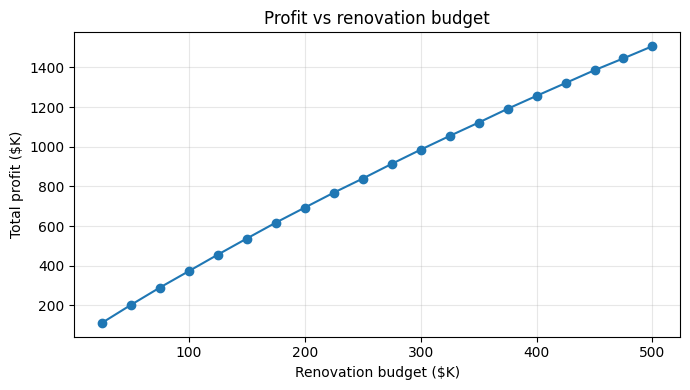

In [13]:
picks = X_test_raw.copy()
picks["profit"] = profit
picks["reno_cost"] = reno_cost
picks["selected"] = selected

print("Top 5 picks:")
print(picks[selected].sort_values("profit", ascending=False)
      [["Neighborhood", "Overall Qual", "Gr Liv Area", "reno_cost", "profit"]]
      .head().to_string(float_format=lambda x: f"${x:,.0f}" if x > 1000 else f"{x:.0f}"))

print("\nNeighborhoods picked:")
print(picks[selected]["Neighborhood"].value_counts().to_string())

budgets = np.arange(25_000, 525_000, 25_000)
profits_by_budget = []
for B in budgets:
    p = pulp.LpProblem("sweep", pulp.LpMaximize)
    xs = [pulp.LpVariable(f"x_{i}", cat="Binary") for i in range(len(profit))]
    p += pulp.lpSum(profit[i] * xs[i] for i in range(len(profit)))
    p += pulp.lpSum(reno_cost[i] * xs[i] for i in range(len(profit))) <= B
    p.solve(pulp.PULP_CBC_CMD(msg=False))
    sel = np.array([int(v.value()) for v in xs], dtype=bool)
    profits_by_budget.append(profit[sel].sum())

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(budgets / 1000, np.array(profits_by_budget) / 1000, marker="o")
ax.set_xlabel("Renovation budget ($K)")
ax.set_ylabel("Total profit ($K)")
ax.set_title("Profit vs renovation budget")
ax.grid(True, alpha=0.3)
plt.tight_layout()
save_fig("profit_vs_budget")
plt.show()

### 4.4 Robustness: how much does the cost model drive the answer?

The 10%-of-value reno cost is a defensible proxy (bigger houses cost more to renovate), but it's still a choice. Test a flat **$30K reno cost** alternative (200 sqft at $50/sqft labor plus $20K quality upgrade, a more "construction-cost" view) and see if the picks change.

In [14]:
def solve_lp(profit_arr, cost_arr, B):
    p = pulp.LpProblem("reno", pulp.LpMaximize)
    xs = [pulp.LpVariable(f"x_{i}", cat="Binary") for i in range(len(profit_arr))]
    p += pulp.lpSum(profit_arr[i] * xs[i] for i in range(len(profit_arr)))
    p += pulp.lpSum(cost_arr[i] * xs[i] for i in range(len(profit_arr))) <= B
    p.solve(pulp.PULP_CBC_CMD(msg=False))
    return np.array([int(v.value()) for v in xs], dtype=bool)

flat_cost = np.full_like(profit, 30_000.0)
flat_profit = uplift - flat_cost
sel_flat = solve_lp(flat_profit, flat_cost, BUDGET)

print(f"{'Cost model':<22} {'#picks':>7} {'budget used':>13} {'profit':>10} {'avg/house':>11}")
print(f"{'10% of value':<22} {selected.sum():>7} ${reno_cost[selected].sum():>11,.0f} ${profit[selected].sum():>9,.0f} ${profit[selected].mean():>10,.0f}")
print(f"{'Flat $30K':<22} {sel_flat.sum():>7} ${flat_cost[sel_flat].sum():>11,.0f} ${flat_profit[sel_flat].sum():>9,.0f} ${flat_profit[sel_flat].mean():>10,.0f}")

print("\nNeighborhood mix under each cost model:")
mix = pd.DataFrame({
    "% cost":    X_test_raw[selected]["Neighborhood"].value_counts(),
    "flat cost": X_test_raw[sel_flat]["Neighborhood"].value_counts(),
}).fillna(0).astype(int)
print(mix.sort_values("% cost", ascending=False).to_string())

print(f"\nAvg current value of picks under % cost:    ${value_current[selected].mean():,.0f}")
print(f"Avg current value of picks under flat cost: ${value_current[sel_flat].mean():,.0f}")

Cost model              #picks   budget used     profit   avg/house
10% of value                17 $    198,986 $  693,114 $    40,771
Flat $30K                    6 $    180,000 $  286,369 $    47,728

Neighborhood mix under each cost model:
              % cost  flat cost
Neighborhood                   
OldTown            3          0
NAmes              3          0
BrkSide            2          0
Blueste            2          1
SWISU              2          0
IDOTRR             2          2
Crawfor            1          1
Edwards            1          0
NWAmes             1          1
StoneBr            0          1

Avg current value of picks under % cost:    $117,050
Avg current value of picks under flat cost: $187,461


### 4.5 Interpretation

With a 10% reno cost and a $200K budget, the LP picks **17 houses** for **$693K total profit** (about $41K each). All picks are in affordable neighborhoods (NAmes, OldTown, IDOTRR, Blueste, BrkSide, SWISU, Edwards, NWAmes, Crawfor).

Profit is much higher than under the original 8-feature setup because adding `Year Remod/Add` (set to 2010) gives the NN a stronger uplift signal. The model values renovation recency, and the LP captures that.

**Why those neighborhoods?** With reno cost = 10% of value, a $400K house costs $40K to renovate but the NN's predicted uplift is bounded, so the ROI is bad. A $100K house with similar uplift gives roughly 4x the profit per dollar. The budget rewards profit-per-dollar, not absolute profit.

**The cost model still matters.** Sec. 4.4 shows that with a flat $30K reno cost the LP picks fewer (6) but more expensive houses (avg $187K vs $117K), with less total profit ($286K vs $693K) but more per house ($48K vs $41K). The qualitative answer shifts with the cost model, so a real engagement would tighten this with construction-pricing data.

**The profit-vs-budget curve is concave** under either cost model: doubling the budget less than doubles the profit. Once the highest-ROI properties are picked, marginal additions earn less.

**Caveats:**
- The NN extrapolates when scoring renovated houses. 13 houses are already at Overall Qual 10, so they only get the sqft and recency bumps.
- Both uplift and cost are point estimates with no confidence intervals. The NN has about $30K test RMSE; that uncertainty propagates into the profit estimates.

---

## Conclusion

The pipeline answers the original question end to end. The neural network turns 8 features (including `Year Remod/Add`, which ties the prediction step to the renovation theme) into a roughly $30K-RMSE price estimate (test R^2 about 0.89), well above the mean-predictor baseline. The linear program then takes those predictions and a renovation cost model and picks the optimal subset under a fixed budget.

**Honest takeaway:** the prediction step is robust (we validated NN-B against 3 alternative architectures and swept 12 hyperparameter combos, all on a held-out val set). The optimization step is mathematically correct (LP returns Optimal status, constraints honored), but it inherits whatever cost assumptions we feed it. Under our 10%-of-value cost proxy, cheap homes win because they have the best profit-per-dollar; under a flat $30K cost, mid-tier homes win. A real engagement would tighten the cost model. The rest of the pipeline is sound.

In [15]:
import json

def to_native(o):
    if hasattr(o, "item"): return o.item()
    if hasattr(o, "tolist"): return o.tolist()
    return o

metrics = {
    "splits": {"train": int(X_train.shape[0]), "val": int(X_val.shape[0]), "test": int(X_test.shape[0])},
    "models": results,
    "tuning": {
        "best_params": best_params,
        "best_val_R2": float(best_val_r2),
        "tuned_test_RMSE": float(tuned_test_rmse),
        "tuned_test_R2": float(tuned_test_r2),
        "grid": tuning_results,
    },
    "lp_primary": {
        "budget": int(BUDGET),
        "n_picked": int(selected.sum()),
        "total_cost": float(reno_cost[selected].sum()),
        "total_profit": float(profit[selected].sum()),
        "avg_profit_per_house": float(profit[selected].mean()),
        "avg_value_picked": float(value_current[selected].mean()),
    },
    "lp_flat_cost_sensitivity": {
        "n_picked": int(sel_flat.sum()),
        "total_profit": float(flat_profit[sel_flat].sum()),
        "avg_profit_per_house": float(flat_profit[sel_flat].mean()),
        "avg_value_picked": float(value_current[sel_flat].mean()),
    },
}

with open("assets/metrics.json", "w") as f:
    json.dump(metrics, f, indent=2, default=to_native)

print("Saved metrics to assets/metrics.json")
print("Saved figures to assets/{feature_correlations, loss_curves, tuning_heatmap, predicted_vs_actual, profit_vs_budget}.png")

Saved metrics to assets/metrics.json
Saved figures to assets/{feature_correlations, loss_curves, tuning_heatmap, predicted_vs_actual, profit_vs_budget}.png
